<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/Tarea_AgrupamientoTextos_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 Mayo de 2026

Materia: Procesamiento de Lenguaje Natural

Ejercicios: Agrupamiento de textos

### ACTIVIDAD
En esta actividad se deberán aplicar técnicas de clustering sobre un conjunto de textos en inglés. Entrenar tus propios embeddings para crear las representaciones vectoriales, las cuales se deberán utilizar para entrenar los algoritmos K-Means y DBSCAN. Compara sus resultados utilizando las métricas internas de evaluación vistas en clase y genera visualizaciones para interpretar los agrupamientos generados por ambos algoritmos. En base a las métricas define el mejor modelo y, para kmeans, el mejor valor de K.

### Instrucciones:

1.	Carga y preparación de datos

    a)	Utiliza el dataset: 20 Newsgroups (sklearn.datasets.fetch_20newsgroups). Esta es la manera de utilizarlo:
    
    b)	Realiza el preprocesamiento del texto, incluyendo como mínimo:
  * Conversión a minúsculas
  *	Eliminación de signos de puntuación
  * Eliminación de stopwords en inglés
  * Tokenización
    
  c)	Entrena tus propios embeddings. Los vectores deben ser de tamaño 100.

In [ ]:
!pip install scikit-learn pandas nltk gensim

In [81]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from itertools import product
from collections import Counter

from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from wordcloud import WordCloud


In [70]:
# -- Descargas de NLTK --
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'punkt_tab',
            'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

# -- Constantes --
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
VECTOR_SIZE = 100   # ← Tamaño del vector

In [71]:
#  SECCIÓN: CARGA Y PREPARACIÓN DE DATOS

# 1 a) Carga del dataset
def readDataset(docs_raw, targets, target_names):
    """Construye el DataFrame a partir de fetch_20newsgroups."""
    df = pd.DataFrame({
        'documento':    docs_raw,
        'etiqueta_num': targets,
        'categoria':    [target_names[i] for i in targets]
    })
    print("=== Primeras filas ===")
    print(df.head())
    print(f"\n=== Dimensiones del dataset: {df.shape} ===")
    print(f"\n=== Valores nulos ===\n{df.isnull().sum()}")
    print(f"\n=== Distribución de categorías ===\n{df['categoria'].value_counts()}")
    return df


# 1 b)Preprocesamiento
def get_wordnet_pos(treebank_tag):
    """Mapea POS tag de NLTK → WordNet para lematización."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def preprocess(text):
    """Pipeline de limpieza:
    1. Encabezados residuales  2. Emails/URLs  3. HTML
    4. Solo letras  5. Minúsculas  6. Tokenizar
    7. POS tagging  8. Stopwords + palabras cortas  9. Lematizar
    """
    text = str(text)
    text = re.sub(r'^(From|Subject|Organization|Lines|NNTP-Posting-Host):.*$',
                  ' ', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens   = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    tokens   = [
        LEMMATIZER.lemmatize(word, pos=get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in STOP_WORDS and len(word) > 2
    ]
    return tokens


def preprocess_dataset(df):
    """Limpia y preprocesa el DataFrame completo."""
    print("\n🔧 Preprocesando texto…")
    before = len(df)

    df.dropna(subset=['documento', 'categoria'], inplace=True)
    df.drop_duplicates(subset=['documento'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   Filas eliminadas (nulos/duplicados): {before - len(df)}")

    df['cleaned'] = df['documento'].apply(preprocess)
    df['num_tokens'] = df['cleaned'].apply(len)

    empty = (df['num_tokens'] == 0).sum()
    df = df[df['num_tokens'] > 0].reset_index(drop=True)
    print(f"   Documentos vacíos eliminados       : {empty}")
    print(f"   Filas finales                      : {len(df)}")

    print("\n   Ejemplos (antes → después):")
    for i in range(min(3, len(df))):
        raw = df['documento'].iloc[i][:60].replace('\n', ' ')
        cln = ' '.join(df['cleaned'].iloc[i][:8])
        print(f"   [{i}] {raw}...")
        print(f"       → {cln}...")
    return df

In [72]:
# Ejecutar Sección 1
print("=" * 60)
print("SECCIÓN 1: Carga y preparación de datos")
print("=" * 60)

dataset  = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs_raw = dataset.data

df = readDataset(docs_raw, dataset.target, dataset.target_names)
df = preprocess_dataset(df)

print(f"\n=== DataFrame final ===")
print(df[['documento', 'categoria', 'cleaned']].head())
print(f"Dimensiones finales: {df.shape}")

corpus_tokens = df['cleaned'].tolist()

SECCIÓN 1: Carga y preparación de datos
=== Primeras filas ===
                                           documento  etiqueta_num  \
0  \n\nI am sure some bashers of Pens fans are pr...            10   
1  My brother is in the market for a high-perform...             3   
2  \n\n\n\n\tFinally you said what you dream abou...            17   
3  \nThink!\n\nIt's the SCSI card doing the DMA t...             3   
4  1)    I have an old Jasmine drive which I cann...             4   

                  categoria  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  

=== Dimensiones del dataset: (18846, 3) ===

=== Valores nulos ===
documento       0
etiqueta_num    0
categoria       0
dtype: int64

=== Distribución de categorías ===
categoria
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                  

In [73]:
# SECCIÓN 1 c): ENTRENAMIENTO DE EMBEDDINGS (Vector size=100)
#  → Word2Vec (promedio) + Doc2Vec (PV-DM)


# =============================================================
# 1 c)- WORD2VEC
# =============================================================
print("\n" + "=" * 60)
print("SECCIÓN 1 c) Word2Vec (vector_size=100)")
print("=" * 60)

w2v_model = Word2Vec(
    sentences=corpus_tokens,
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=5,
    workers=4,
    sg=1,           # Skip-gram
    epochs=20,
    seed=42
)

print(f"   Arquitectura        : Skip-gram (sg=1)")
print(f"   Tamaño del vector   : {w2v_model.vector_size}")
print(f"   Ventana de contexto : {w2v_model.window}")
print(f"   Vocabulario         : {len(w2v_model.wv)} palabras")
print(f"   Épocas              : {w2v_model.epochs}")
print(f"   min_count           : {w2v_model.min_count}")

word_example = "computer"
if word_example in w2v_model.wv:
    print(f"\n   Top 5 similares a '{word_example}':")
    for w, s in w2v_model.wv.most_similar(word_example, topn=5):
        print(f"      {w:<20} {s:.4f}")

pairs = [("god", "religion"), ("car", "drive"), ("space", "nasa")]
print("\n   Similitud entre pares:")
for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        print(f"      {w1:<12} ↔ {w2:<12} = {w2v_model.wv.similarity(w1, w2):.4f}")

w2v_model.save("word2vec_20news_100d.model")
print("   ✅ Modelo guardado: word2vec_20news_100d.model")

# Vectores de documentos (promedio)
def doc_vector(tokens, model):
    """Promedio de vectores Word2Vec de las palabras del documento."""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

print("\n   📄 Generando vectores de documentos (promedio W2V)...")
X_w2v_raw = np.array([doc_vector(doc, w2v_model) for doc in corpus_tokens])
print(f"   Matriz X_w2v (sin normalizar): {X_w2v_raw.shape}")


SECCIÓN 1 c) Word2Vec (vector_size=100)
   Arquitectura        : Skip-gram (sg=1)
   Tamaño del vector   : 100
   Ventana de contexto : 5
   Vocabulario         : 20026 palabras
   Épocas              : 20
   min_count           : 5

   Top 5 similares a 'computer':
      itti                 0.6468
      visualisation        0.6130
      graphic              0.6095
      berne                0.6030
      electronic           0.5895

   Similitud entre pares:
      god          ↔ religion     = 0.5309
      car          ↔ drive        = 0.4251
      space        ↔ nasa         = 0.6567
   ✅ Modelo guardado: word2vec_20news_100d.model

   📄 Generando vectores de documentos (promedio W2V)...
   Matriz X_w2v (sin normalizar): (18233, 100)


In [74]:
# =============================================================
# 1 c) DOC2VEC
# =============================================================
print("\n" + "=" * 60)
print("SECCIÓN 1 c) Doc2Vec (vector_size=100)")
print("=" * 60)

tagged_docs = [
    TaggedDocument(words=tokens, tags=[str(i)])
    for i, tokens in enumerate(corpus_tokens)
]

d2v_model = Doc2Vec(
    documents=tagged_docs,
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=5,
    workers=4,
    dm=1,           # PV-DM (Distributed Memory)
    epochs=20,
    seed=42
)

print(f"   Arquitectura        : PV-DM (dm=1)")
print(f"   Tamaño del vector   : {d2v_model.vector_size}")
print(f"   Vocabulario         : {len(d2v_model.wv)} palabras")
print(f"   Documentos          : {len(d2v_model.dv)} vectores")

X_d2v_raw = np.array([d2v_model.dv[str(i)] for i in range(len(df))])
print(f"   Matriz X_d2v (sin normalizar): {X_d2v_raw.shape}")

print("\n   Top 5 docs similares al documento 0:")
for doc_id, score in d2v_model.dv.most_similar('0', topn=5):
    cat = df['categoria'].iloc[int(doc_id)]
    print(f"      Doc {doc_id:<6} ({cat:<30}) sim: {score:.4f}")

nuevo_tokens = preprocess("The space shuttle launched successfully into orbit")
vector_nuevo = d2v_model.infer_vector(nuevo_tokens)
print(f"\n   Inferencia doc nuevo → vector: {vector_nuevo[:5]}... (100 dims)")

d2v_model.save("doc2vec_20news_100d.model")
print("   ✅ Modelo guardado: doc2vec_20news_100d.model")


SECCIÓN 1 c) Doc2Vec (vector_size=100)
   Arquitectura        : PV-DM (dm=1)
   Tamaño del vector   : 100
   Vocabulario         : 20026 palabras
   Documentos          : 18233 vectores
   Matriz X_d2v (sin normalizar): (18233, 100)

   Top 5 docs similares al documento 0:
      Doc 2626   (rec.sport.hockey              ) sim: 0.6573
      Doc 16436  (rec.sport.hockey              ) sim: 0.6561
      Doc 8484   (rec.sport.hockey              ) sim: 0.6437
      Doc 6630   (rec.sport.hockey              ) sim: 0.6381
      Doc 16771  (sci.space                     ) sim: 0.6335

   Inferencia doc nuevo → vector: [ 0.11531199  0.07410052 -0.23059765 -0.17534323 -0.13924313]... (100 dims)
   ✅ Modelo guardado: doc2vec_20news_100d.model


In [75]:
# NORMALIZACIÓN L2 DE EMBEDDINGS
# =============================================================
# ¿Por qué normalizar?
#
# 1. K-Means usa distancia euclidiana para asignar puntos a
#    centroides. Si las dimensiones tienen escalas distintas,
#    unas pesan más que otras → clústeres sesgados.
#
# 2. DBSCAN usa eps como radio fijo. Sin normalizar, el rango
#    de distancias varía mucho entre Word2Vec y Doc2Vec,
#    haciendo difícil comparar y elegir eps.
#
# 3. Normalización L2 lleva cada vector a norma unitaria (‖x‖=1).
#    Tras esto, la distancia euclidiana es proporcional a la
#    similitud coseno:
#
#       ‖a - b‖² = 2 · (1 - cos(a, b))
#
#    Esto hace que K-Means agrupe por SIMILITUD SEMÁNTICA
#    en lugar de por magnitud del vector.
#
# 4. Las métricas (Silhouette, DBI, CH) se vuelven comparables
#    entre ambos embeddings porque operan en la misma escala.
# =============================================================

print("\n" + "=" * 60)
print("SECCIÓN 1c-C: Normalización L2 de embeddings")
print("=" * 60)

# Estadísticas ANTES de normalizar
print("\n   --- ANTES de normalizar ---")
print(f"   Word2Vec → norma promedio: {np.linalg.norm(X_w2v_raw, axis=1).mean():.4f}, "
      f"std: {np.linalg.norm(X_w2v_raw, axis=1).std():.4f}")
print(f"              rango valores : [{X_w2v_raw.min():.4f}, {X_w2v_raw.max():.4f}]")
print(f"   Doc2Vec  → norma promedio: {np.linalg.norm(X_d2v_raw, axis=1).mean():.4f}, "
      f"std: {np.linalg.norm(X_d2v_raw, axis=1).std():.4f}")
print(f"              rango valores : [{X_d2v_raw.min():.4f}, {X_d2v_raw.max():.4f}]")

# Aplicar normalización L2
X_w2v = normalize(X_w2v_raw, norm='l2')
X_d2v = normalize(X_d2v_raw, norm='l2')

# Estadísticas DESPUÉS de normalizar
print("\n   --- DESPUÉS de normalizar (L2) ---")
print(f"   Word2Vec → norma promedio: {np.linalg.norm(X_w2v, axis=1).mean():.4f}, "
      f"std: {np.linalg.norm(X_w2v, axis=1).std():.6f}")
print(f"              rango valores : [{X_w2v.min():.4f}, {X_w2v.max():.4f}]")
print(f"   Doc2Vec  → norma promedio: {np.linalg.norm(X_d2v, axis=1).mean():.4f}, "
      f"std: {np.linalg.norm(X_d2v, axis=1).std():.6f}")
print(f"              rango valores : [{X_d2v.min():.4f}, {X_d2v.max():.4f}]")

print("\n   Todos los vectores tienen norma = 1.0000")
print("     Distancia euclidiana ahora es proporcional a similitud coseno")
print("     Métricas comparables entre Word2Vec y Doc2Vec")

# Resumen comparativo de embeddings
print(f"""
   ┌────────────────────┬───────────────────┬───────────────────┐
   │     Aspecto        │    Word2Vec       │    Doc2Vec        │
   ├────────────────────┼───────────────────┼───────────────────┤
   │ vector_size        │ {VECTOR_SIZE:<17} │ {VECTOR_SIZE:<17} │
   │ Forma de X         │ {str(X_w2v.shape):<17} │ {str(X_d2v.shape):<17} │
   │ Vocabulario        │ {len(w2v_model.wv):<17} │ {len(d2v_model.wv):<17} │
   │ Arquitectura       │ {'Skip-gram':<17} │ {'PV-DM':<17} │
   │ Nivel              │ {'Palabra→Promedio':<17} │ {'Documento':<17} │
   │ Normalización      │ {'L2 (norma=1)':<17} │ {'L2 (norma=1)':<17} │
   └────────────────────┴───────────────────┴───────────────────┘
""")


SECCIÓN 1c-C: Normalización L2 de embeddings

   --- ANTES de normalizar ---
   Word2Vec → norma promedio: 1.8254, std: 0.3001
              rango valores : [-1.6525, 1.9745]
   Doc2Vec  → norma promedio: 3.1880, std: 2.5719
              rango valores : [-8.9774, 9.5135]

   --- DESPUÉS de normalizar (L2) ---
   Word2Vec → norma promedio: 0.9995, std: 0.023413
              rango valores : [-0.4634, 0.4064]
   Doc2Vec  → norma promedio: 1.0000, std: 0.000000
              rango valores : [-0.4888, 0.4700]

   Todos los vectores tienen norma = 1.0000
     Distancia euclidiana ahora es proporcional a similitud coseno
     Métricas comparables entre Word2Vec y Doc2Vec

   ┌────────────────────┬───────────────────┬───────────────────┐
   │     Aspecto        │    Word2Vec       │    Doc2Vec        │
   ├────────────────────┼───────────────────┼───────────────────┤
   │ vector_size        │ 100               │ 100               │
   │ Forma de X         │ (18233, 100)      │ (18233, 100) 

In [76]:
#FUNCIONES REUTILIZABLES PARA AMBOS EMBEDDINGS

def buscar_k_optimo(X, K_range, emb_name):
    """Evalúa K-Means para un rango de K y retorna métricas + K óptimo."""
    inertias   = []
    sil_scores = []

    print(f"\n   Evaluando K de {K_range[0]} a {K_range[-1]} ({emb_name})...")
    for k in K_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, lab))
        print(f"   K={k:2d}  Inercia={km.inertia_:>12.4f}  "
              f"Silhouette={sil_scores[-1]:.4f}")

    K_optimo = list(K_range)[np.argmax(sil_scores)]
    return inertias, sil_scores, K_optimo


def graficar_codo_silhouette(K_range, inertias, sil_scores, K_optimo, emb_name):
    """Genera gráficas del Codo y Silhouette lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
    axes[0].axvline(x=K_optimo, color='green', linestyle='--',
                    label=f'K óptimo = {K_optimo}')
    axes[0].set_xlabel('K (número de clústeres)')
    axes[0].set_ylabel('Inercia (WCSS)')
    axes[0].set_title(f'Método del Codo — {emb_name} (normalizado L2)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
    axes[1].axvline(x=K_optimo, color='green', linestyle='--',
                    label=f'K óptimo = {K_optimo}')
    axes[1].set_xlabel('K (número de clústeres)')
    axes[1].set_ylabel('Coeficiente Silhouette')
    axes[1].set_title(f'Silhouette por K — {emb_name} (normalizado L2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'kmeans_elbow_sil_{emb_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def entrenar_kmeans_final(X, K_optimo, emb_name):
    """Entrena K-Means con K óptimo y calcula métricas."""
    print(f"\n   Reentrenando K-Means con K={K_optimo} ({emb_name})...")
    km = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    print(f"   Documentos por clúster: {np.bincount(labels)}")

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    print(f"\n   === Métricas K-Means {emb_name} (K={K_optimo}) ===")
    print(f"   Silhouette         : {sil:.4f}   (↑ mejor)")
    print(f"   Davies-Bouldin     : {dbi:.4f}   (↓ mejor)")
    print(f"   Calinski-Harabasz  : {ch:.2f}    (↑ mejor)")

    return labels, {'Silhouette': sil, 'DBI': dbi, 'CH': ch, 'K': K_optimo}


def buscar_dbscan(X, emb_name):
    """Explora hiperparámetros de DBSCAN y retorna los mejores.

    Nota: tras la normalización L2 todos los vectores tienen
    norma=1, por lo que las distancias euclidianas están en el
    rango [0, 2]. Esto permite usar valores de eps más pequeños
    y consistentes entre ambos embeddings.
    """
    eps_values = [0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
    min_samples_values = [3, 5, 10, 15, 20]

    print(f"\n   {'eps':>5} {'min_s':>6} {'Clúst':>6} {'Ruido':>7} "
          f"{'Silhouette':>11}  ({emb_name})")
    print("   " + "-" * 50)

    best_sil    = -1
    best_params = {}

    for eps_val, ms_val in product(eps_values, min_samples_values):
        db  = DBSCAN(eps=eps_val, min_samples=ms_val)
        lab = db.fit_predict(X)

        n_clust = len(set(lab)) - (1 if -1 in lab else 0)
        n_noise = (lab == -1).sum()

        if n_clust >= 2:
            mask = lab != -1
            if mask.sum() > n_clust and len(set(lab[mask])) >= 2:
                sil_val = silhouette_score(X[mask], lab[mask])
                print(f"   {eps_val:5.1f} {ms_val:6d} {n_clust:6d} "
                      f"{n_noise:7d} {sil_val:11.4f}")
                if sil_val > best_sil:
                    best_sil    = sil_val
                    best_params = {'eps': eps_val, 'min_samples': ms_val}

    if not best_params:
        print("   ⚠️ No se encontraron configuraciones válidas con ≥2 clústeres.")
        return None

    print(f"\n   📌 Mejores: eps={best_params['eps']}, "
          f"min_samples={best_params['min_samples']} (Sil={best_sil:.4f})")
    return best_params


def entrenar_dbscan_final(X, params, emb_name):
    """Entrena DBSCAN final y calcula métricas."""
    db     = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X)

    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    mask         = labels != -1
    X_clean      = X[mask]
    labels_clean = labels[mask]

    sil = silhouette_score(X_clean, labels_clean)
    dbi = davies_bouldin_score(X_clean, labels_clean)
    ch  = calinski_harabasz_score(X_clean, labels_clean)

    print(f"\n   === Métricas DBSCAN {emb_name} ===")
    print(f"   eps={params['eps']}, min_samples={params['min_samples']}")
    print(f"   Clústeres           : {n_clust}")
    print(f"   Puntos de ruido     : {n_noise} ({n_noise/len(X)*100:.1f}%)")
    print(f"   Silhouette          : {sil:.4f}   (↑ mejor)")
    print(f"   Davies-Bouldin      : {dbi:.4f}   (↓ mejor)")
    print(f"   Calinski-Harabasz   : {ch:.2f}    (↑ mejor)")

    return labels, {'Silhouette': sil, 'DBI': dbi, 'CH': ch,
                    'Clústeres': n_clust, 'Ruido': n_noise}


# =============================================================
# VISUALIZACIÓN CON PCA (método lineal)
# =============================================================
def graficar_pca(X, labels_km, labels_db, K_opt, db_params, emb_name):
    """Genera gráficas PCA 2D para K-Means y DBSCAN."""
    print(f"\n   📐 Calculando PCA 2D para {emb_name}...")
    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)
    print(f"   ✅ PCA completado. Varianza explicada: "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_km,
                          cmap='tab20', s=3, alpha=0.5)
    axes[0].set_title(f'K-Means (K={K_opt}) — PCA — {emb_name}', fontsize=14)
    axes[0].set_xlabel('Componente Principal 1')
    axes[0].set_ylabel('Componente Principal 2')
    plt.colorbar(sc1, ax=axes[0], label='Clúster')

    colors_db = labels_db.astype(float)
    sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_db,
                          cmap='tab20', s=3, alpha=0.5)
    noise_mask = labels_db == -1
    if noise_mask.any():
        axes[1].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                        c='gray', s=1, alpha=0.3,
                        label=f'Ruido ({noise_mask.sum()})')
        axes[1].legend(fontsize=10)
    axes[1].set_title(f'DBSCAN (eps={db_params["eps"]}, '
                      f'min_s={db_params["min_samples"]}) — PCA — {emb_name}',
                      fontsize=14)
    axes[1].set_xlabel('Componente Principal 1')
    axes[1].set_ylabel('Componente Principal 2')
    plt.colorbar(sc2, ax=axes[1], label='Clúster (-1=ruido)')

    plt.tight_layout()
    plt.savefig(f'pca_{emb_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================
# VISUALIZACIÓN CON t-SNE (método no lineal)
# =============================================================
def graficar_tsne(X, labels_km, labels_db, K_opt, db_params, emb_name):
    """Genera gráficas t-SNE 2D para K-Means y DBSCAN."""
    print(f"\n   ⏳ Calculando t-SNE 2D para {emb_name}... (puede tardar ~2-5 min)")
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        n_iter=1000,
        random_state=42,
        init='pca'
    )
    X_2d = tsne.fit_transform(X)
    print(f"   ✅ t-SNE completado. Forma: {X_2d.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_km,
                          cmap='tab20', s=3, alpha=0.5)
    axes[0].set_title(f'K-Means (K={K_opt}) — t-SNE — {emb_name}', fontsize=14)
    axes[0].set_xlabel('t-SNE dim 1')
    axes[0].set_ylabel('t-SNE dim 2')
    plt.colorbar(sc1, ax=axes[0], label='Clúster')

    colors_db = labels_db.astype(float)
    sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_db,
                          cmap='tab20', s=3, alpha=0.5)
    noise_mask = labels_db == -1
    if noise_mask.any():
        axes[1].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                        c='gray', s=1, alpha=0.3,
                        label=f'Ruido ({noise_mask.sum()})')
        axes[1].legend(fontsize=10)
    axes[1].set_title(f'DBSCAN (eps={db_params["eps"]}, '
                      f'min_s={db_params["min_samples"]}) — t-SNE — {emb_name}',
                      fontsize=14)
    axes[1].set_xlabel('t-SNE dim 1')
    axes[1].set_ylabel('t-SNE dim 2')
    plt.colorbar(sc2, ax=axes[1], label='Clúster (-1=ruido)')

    plt.tight_layout()
    plt.savefig(f'tsne_{emb_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================
# NUBES DE PALABRAS
# =============================================================
def plot_wordclouds(labels, corpus, title_prefix, max_clusters=6):
    """Genera nubes de palabras para los primeros N clústeres."""
    unique_labels = sorted([l for l in set(labels) if l >= 0])
    n_show = min(len(unique_labels), max_clusters)
    if n_show == 0:
        print(f"   ⚠️ No hay clústeres válidos para {title_prefix}")
        return
    cols = min(n_show, 3)
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    if n_show == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for idx in range(n_show):
        cid = unique_labels[idx]
        tokens = [w for i, doc in enumerate(corpus)
                  if labels[i] == cid for w in doc]
        text = ' '.join(tokens)
        if text.strip():
            wc = WordCloud(width=600, height=400, background_color='white',
                           max_words=40, colormap='viridis').generate(text)
            axes[idx].imshow(wc, interpolation='bilinear')
        axes[idx].set_title(f'{title_prefix} — Clúster {cid}', fontsize=12)
        axes[idx].axis('off')

    for idx in range(n_show, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Nubes de Palabras — {title_prefix}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(f'wc_{title_prefix.lower().replace(" ","_").replace("-","")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

   2.	Clustering con K-Means

a)	Entrena K-Means utilizando los embeddings obtenidos.

b)	Determina el mejor valor de K utilizando:
* Método del Codo (Elbow Method)
* Coeficiente de Silhouette

c)	Muestra las gráficas correspondientes y explica brevemente cómo elegiste el valor óptimo.

d)	Entrena nuevamente K-Means usando ese K óptimo.

e)	Calcula y reporta las métricas:
*   Silhouette
*   Davies–Bouldin Index (DB)
*   Calinski–Harabasz (CH)



  3.	Clustering con DBSCAN

a)	Entrena un modelo DBSCAN utilizando el mismo conjunto de embeddings.

b)	Ajusta los hiperparámetros eps y min_samples (explora varios valores).

c)	Calcula las mismas métricas internas:
* Silhouette
* Davies–Bouldin
* Calinski–Harabasz


4.	Visualizaciones

a)	PCA o tSNE en 2D mostrando los clusters de K-Means

b)	PCA o tSNE en 2D mostrando los clusters de DBSCAN

c)	Nube de palabras por cluster (para ambos modelos)



############################################################
PIPELINE CON WORD2VEC (normalizado L2)
############################################################

   Evaluando K de 2 a 20 (Word2Vec)...
   K= 2  Inercia=   5075.9119  Silhouette=0.1079
   K= 3  Inercia=   4814.5466  Silhouette=0.0956
   K= 4  Inercia=   4628.2205  Silhouette=0.0892
   K= 5  Inercia=   4512.3538  Silhouette=0.0779
   K= 6  Inercia=   4414.2791  Silhouette=0.0641
   K= 7  Inercia=   4325.2873  Silhouette=0.0652
   K= 8  Inercia=   4255.4018  Silhouette=0.0691
   K= 9  Inercia=   4191.8223  Silhouette=0.0698
   K=10  Inercia=   4139.3057  Silhouette=0.0701
   K=11  Inercia=   4089.5291  Silhouette=0.0684
   K=12  Inercia=   4049.7166  Silhouette=0.0697
   K=13  Inercia=   4010.3842  Silhouette=0.0662
   K=14  Inercia=   3974.3123  Silhouette=0.0663
   K=15  Inercia=   3945.3033  Silhouette=0.0625
   K=16  Inercia=   3914.1321  Silhouette=0.0567
   K=17  Inercia=   3884.9487  Silhouette=0.0575
   K=18  Inerc

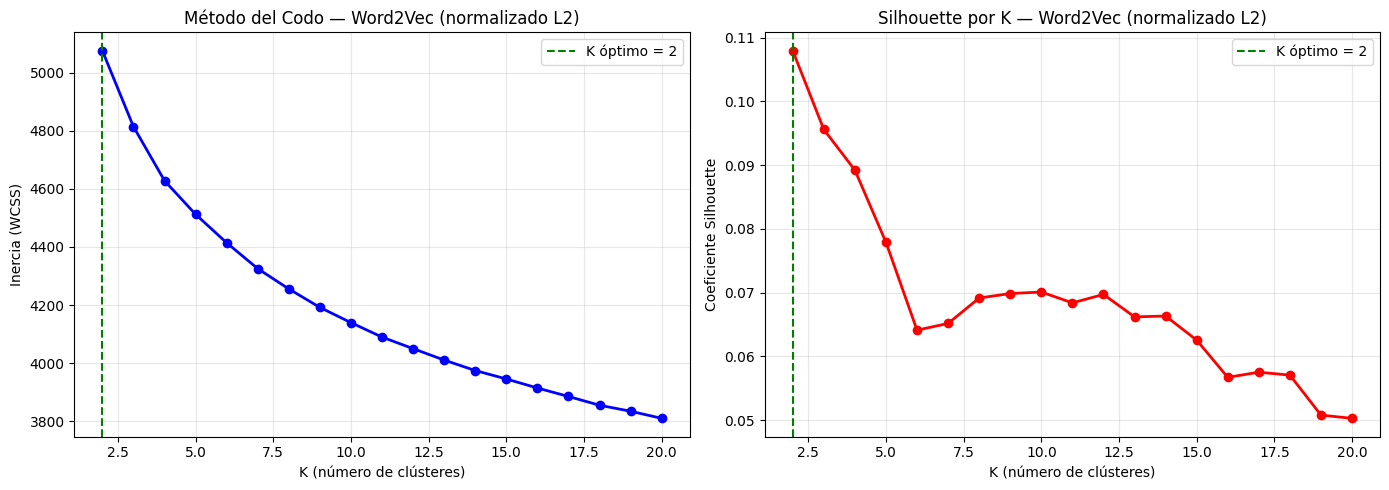


    K óptimo Word2Vec = 2
      Silhouette máximo = 0.1079
      La inercia se estabiliza alrededor de K=2,
      coincidiendo con el máximo del Coeficiente Silhouette.

   Reentrenando K-Means con K=2 (Word2Vec)...
   Documentos por clúster: [11021  7212]

   === Métricas K-Means Word2Vec (K=2) ===
   Silhouette         : 0.1079   (↑ mejor)
   Davies-Bouldin     : 2.7683   (↓ mejor)
   Calinski-Harabasz  : 2156.34    (↑ mejor)

     eps  min_s  Clúst   Ruido  Silhouette  (Word2Vec)
   --------------------------------------------------
     0.3      3    172   14097     -0.1732
     0.3      5     48   14812     -0.0534
     0.3     10     16   15504      0.0982
     0.3     15     10   15934      0.1453
     0.3     20      8   16165      0.1885
     0.5      3     17    2054      0.0752
     0.5      5      7    2115      0.2373
     0.5     10      4    2213      0.2466
     0.7      3      4     164      0.2213
     0.7      5      2     174      0.2296
     0.7     10      2     

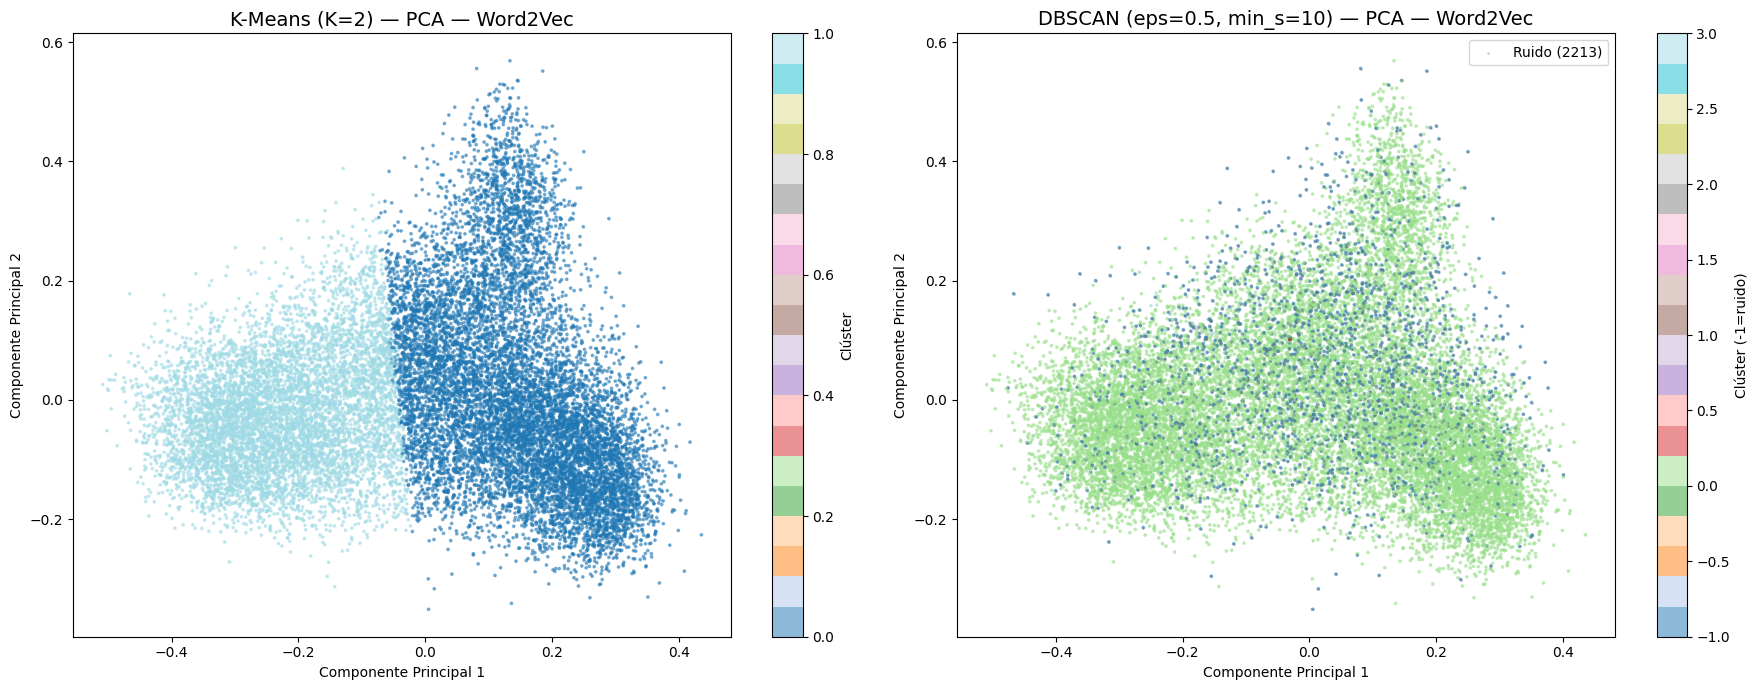


   ⏳ Calculando t-SNE 2D para Word2Vec... (puede tardar ~2-5 min)
   ✅ t-SNE completado. Forma: (18233, 2)


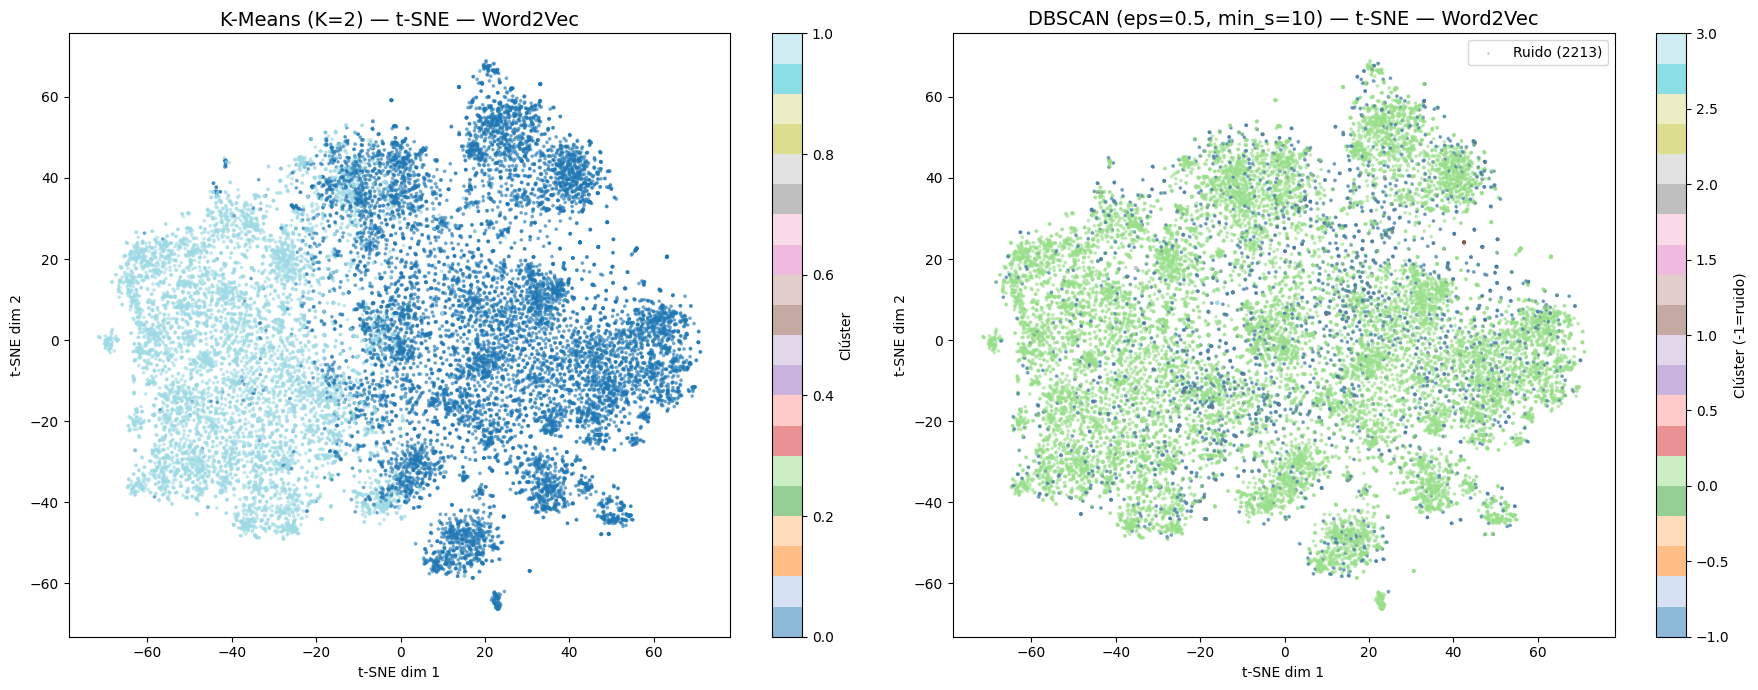

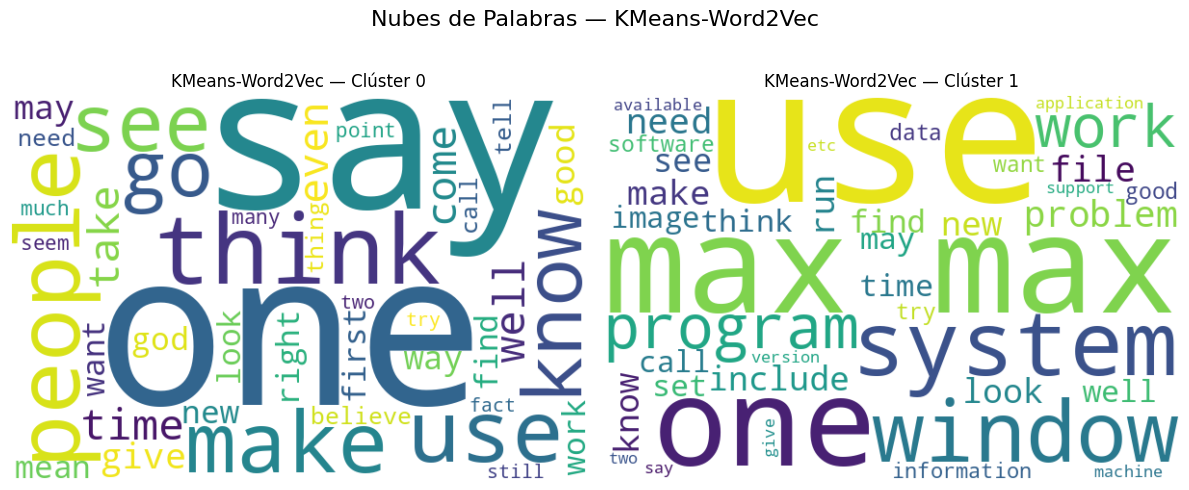

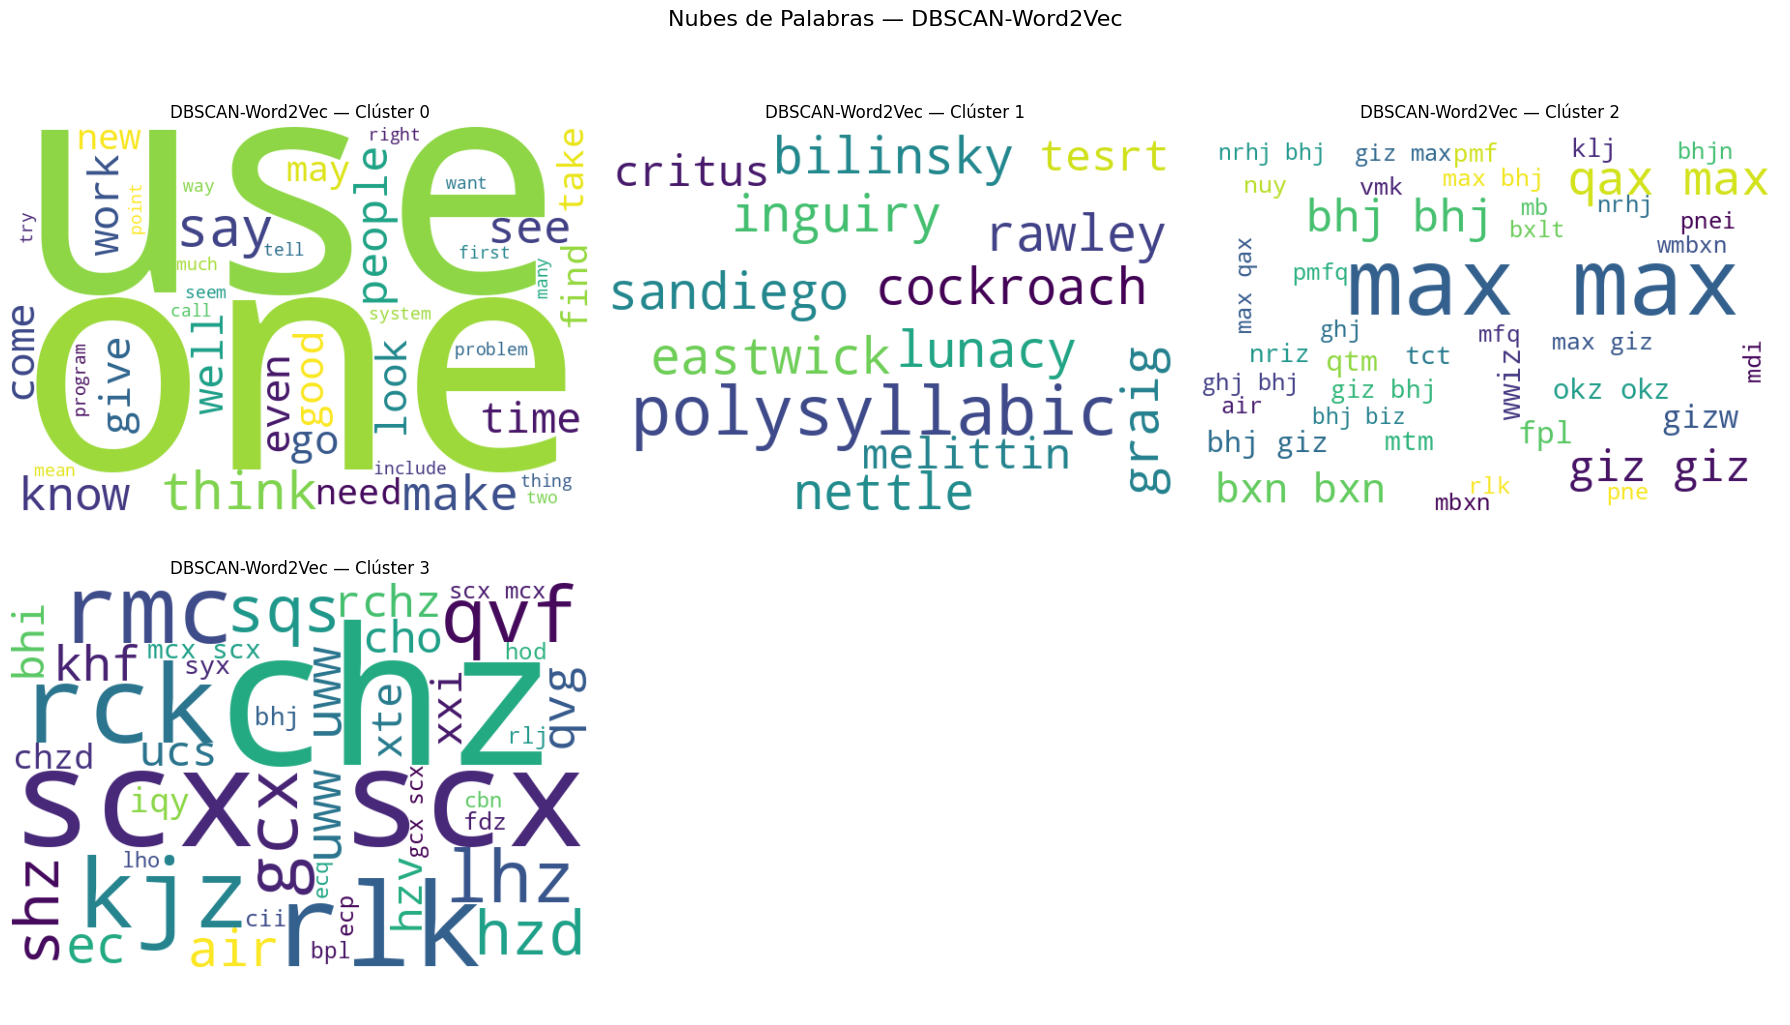

In [77]:
# SECCIÓN 2-4: PIPELINE PARA WORD2VEC

print("\n" + "#" * 60)
print("PIPELINE CON WORD2VEC (normalizado L2)")
print("#" * 60)

# 2a-2c: Buscar K óptimo + gráficas
K_range = range(2, 21)
inertias_w, sil_w, K_opt_w = buscar_k_optimo(X_w2v, K_range, "Word2Vec")
graficar_codo_silhouette(K_range, inertias_w, sil_w, K_opt_w, "Word2Vec")

print(f"\n    K óptimo Word2Vec = {K_opt_w}")
print(f"      Silhouette máximo = {max(sil_w):.4f}")
print(f"      La inercia se estabiliza alrededor de K={K_opt_w},")
print(f"      coincidiendo con el máximo del Coeficiente Silhouette.")

labels_km_w, metrics_km_w = entrenar_kmeans_final(X_w2v, K_opt_w, "Word2Vec")

best_params_w = buscar_dbscan(X_w2v, "Word2Vec")
if best_params_w:
    labels_db_w, metrics_db_w = entrenar_dbscan_final(
        X_w2v, best_params_w, "Word2Vec")
else:
    labels_db_w  = np.full(len(X_w2v), -1)
    metrics_db_w = {'Silhouette': 0, 'DBI': 999, 'CH': 0,
                    'Clústeres': 0, 'Ruido': len(X_w2v)}
    best_params_w = {'eps': 0, 'min_samples': 0}

graficar_pca(X_w2v, labels_km_w, labels_db_w, K_opt_w,
             best_params_w, "Word2Vec")
graficar_tsne(X_w2v, labels_km_w, labels_db_w, K_opt_w,
              best_params_w, "Word2Vec")
plot_wordclouds(labels_km_w, corpus_tokens, "KMeans-Word2Vec")
plot_wordclouds(labels_db_w, corpus_tokens, "DBSCAN-Word2Vec")



############################################################
 PIPELINE CON DOC2VEC (normalizado L2)
############################################################

   Evaluando K de 2 a 20 (Doc2Vec)...
   K= 2  Inercia=  13320.7100  Silhouette=0.0430
   K= 3  Inercia=  12933.2061  Silhouette=0.0347
   K= 4  Inercia=  12644.4766  Silhouette=0.0177
   K= 5  Inercia=  12399.9893  Silhouette=0.0198
   K= 6  Inercia=  12180.1328  Silhouette=0.0245
   K= 7  Inercia=  12028.5928  Silhouette=0.0266
   K= 8  Inercia=  11895.1221  Silhouette=0.0278
   K= 9  Inercia=  11775.6523  Silhouette=0.0311
   K=10  Inercia=  11668.6611  Silhouette=0.0335
   K=11  Inercia=  11589.2783  Silhouette=0.0346
   K=12  Inercia=  11511.1035  Silhouette=0.0325
   K=13  Inercia=  11450.0400  Silhouette=0.0221
   K=14  Inercia=  11390.1064  Silhouette=0.0293
   K=15  Inercia=  11332.7695  Silhouette=0.0197
   K=16  Inercia=  11282.3555  Silhouette=0.0183
   K=17  Inercia=  11238.4092  Silhouette=0.0194
   K=18  Inerci

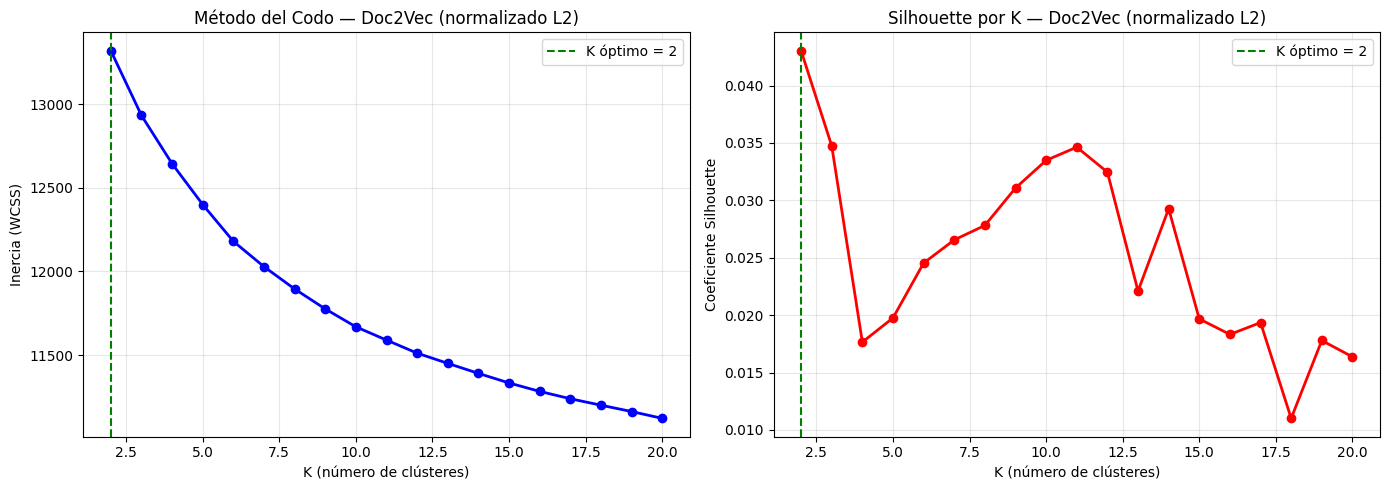


    K óptimo Doc2Vec = 2
      Silhouette máximo = 0.0430
      La inercia se estabiliza alrededor de K=2,
      coincidiendo con el máximo del Coeficiente Silhouette.

   Reentrenando K-Means con K=2 (Doc2Vec)...
   Documentos por clúster: [10368  7865]

   === Métricas K-Means Doc2Vec (K=2) ===
   Silhouette         : 0.0430   (↑ mejor)
   Davies-Bouldin     : 4.9052   (↓ mejor)
   Calinski-Harabasz  : 738.36    (↑ mejor)

     eps  min_s  Clúst   Ruido  Silhouette  (Doc2Vec)
   --------------------------------------------------
     0.3      3     23   18085      0.4379
     0.3      5      9   18132      0.5490
     0.5      3     41   17496      0.1512
     0.5      5     10   17612      0.1247
     0.5     10      2   17683      0.3141
     0.7      3     75   14498      0.0136
     0.7      5     20   14847      0.1197
     0.7     10      2   15086      0.2841
     0.7     15      2   15137      0.1611
     0.9      3      3    2368      0.0583
     0.9     10      2    2699  

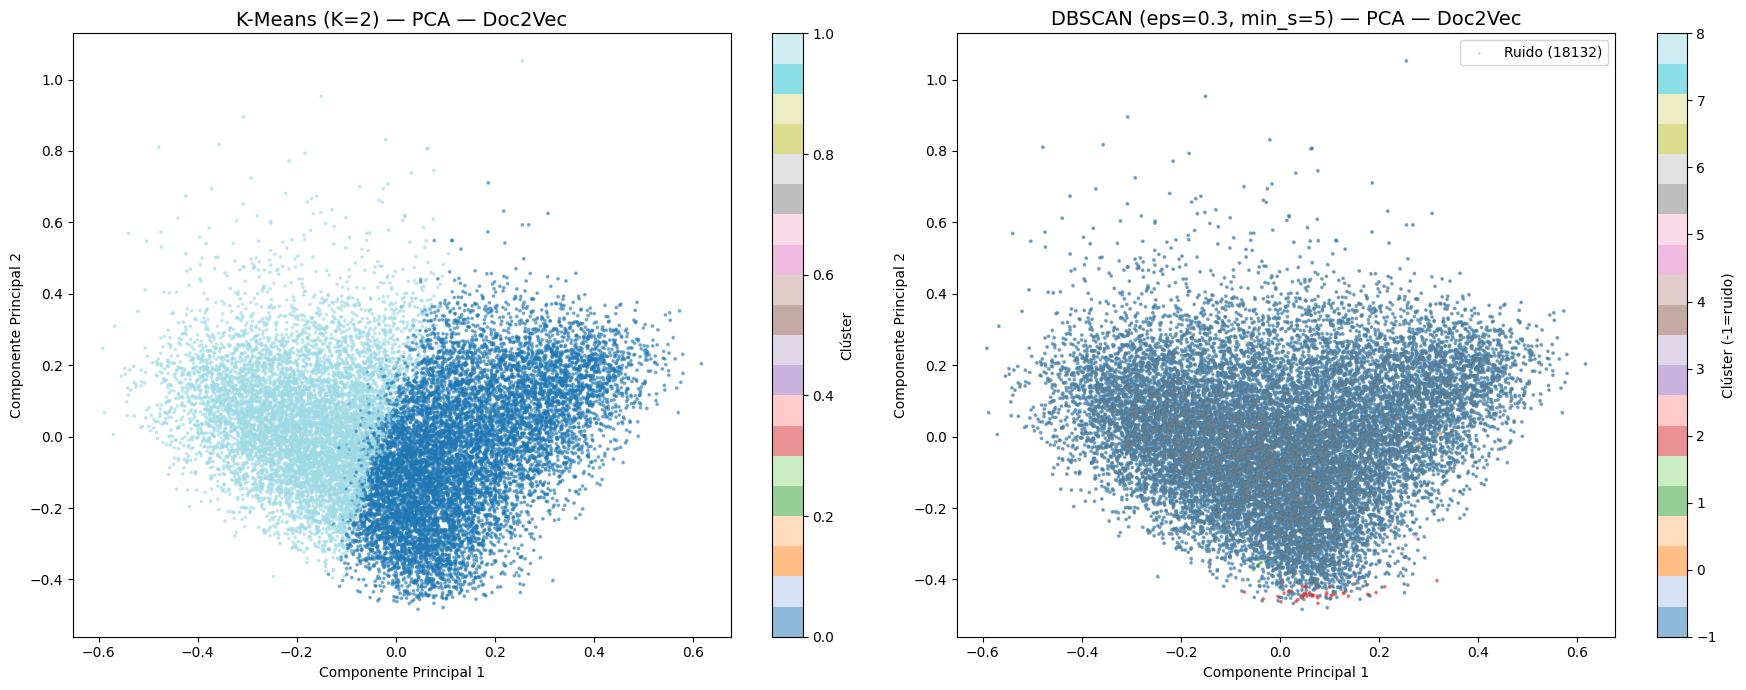


   ⏳ Calculando t-SNE 2D para Doc2Vec... (puede tardar ~2-5 min)
   ✅ t-SNE completado. Forma: (18233, 2)


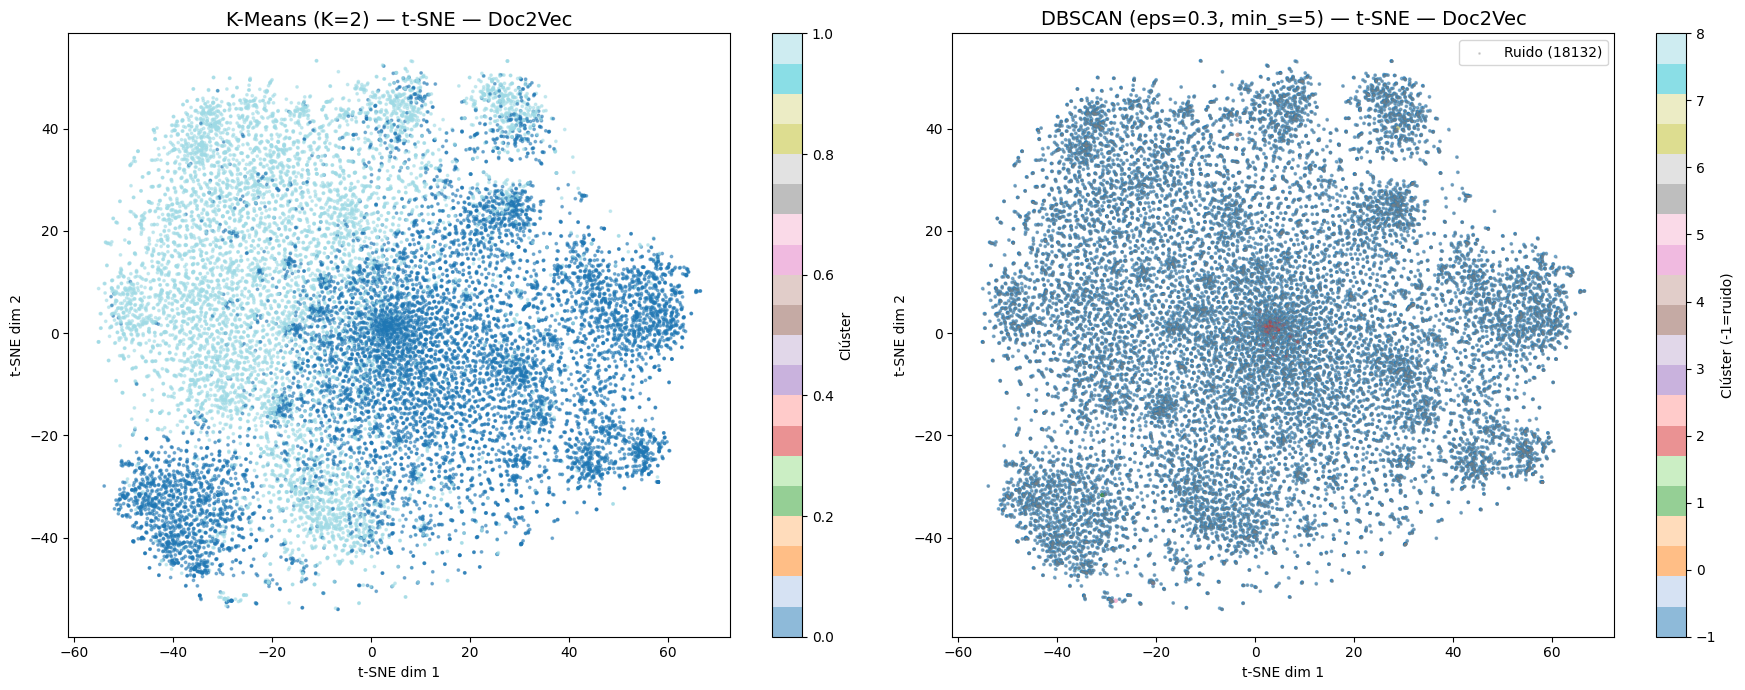

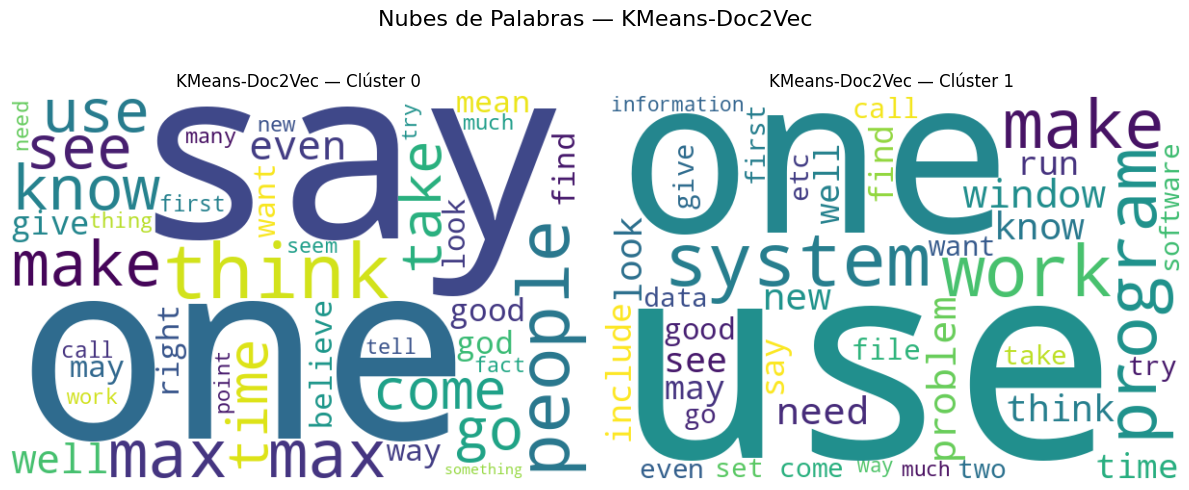

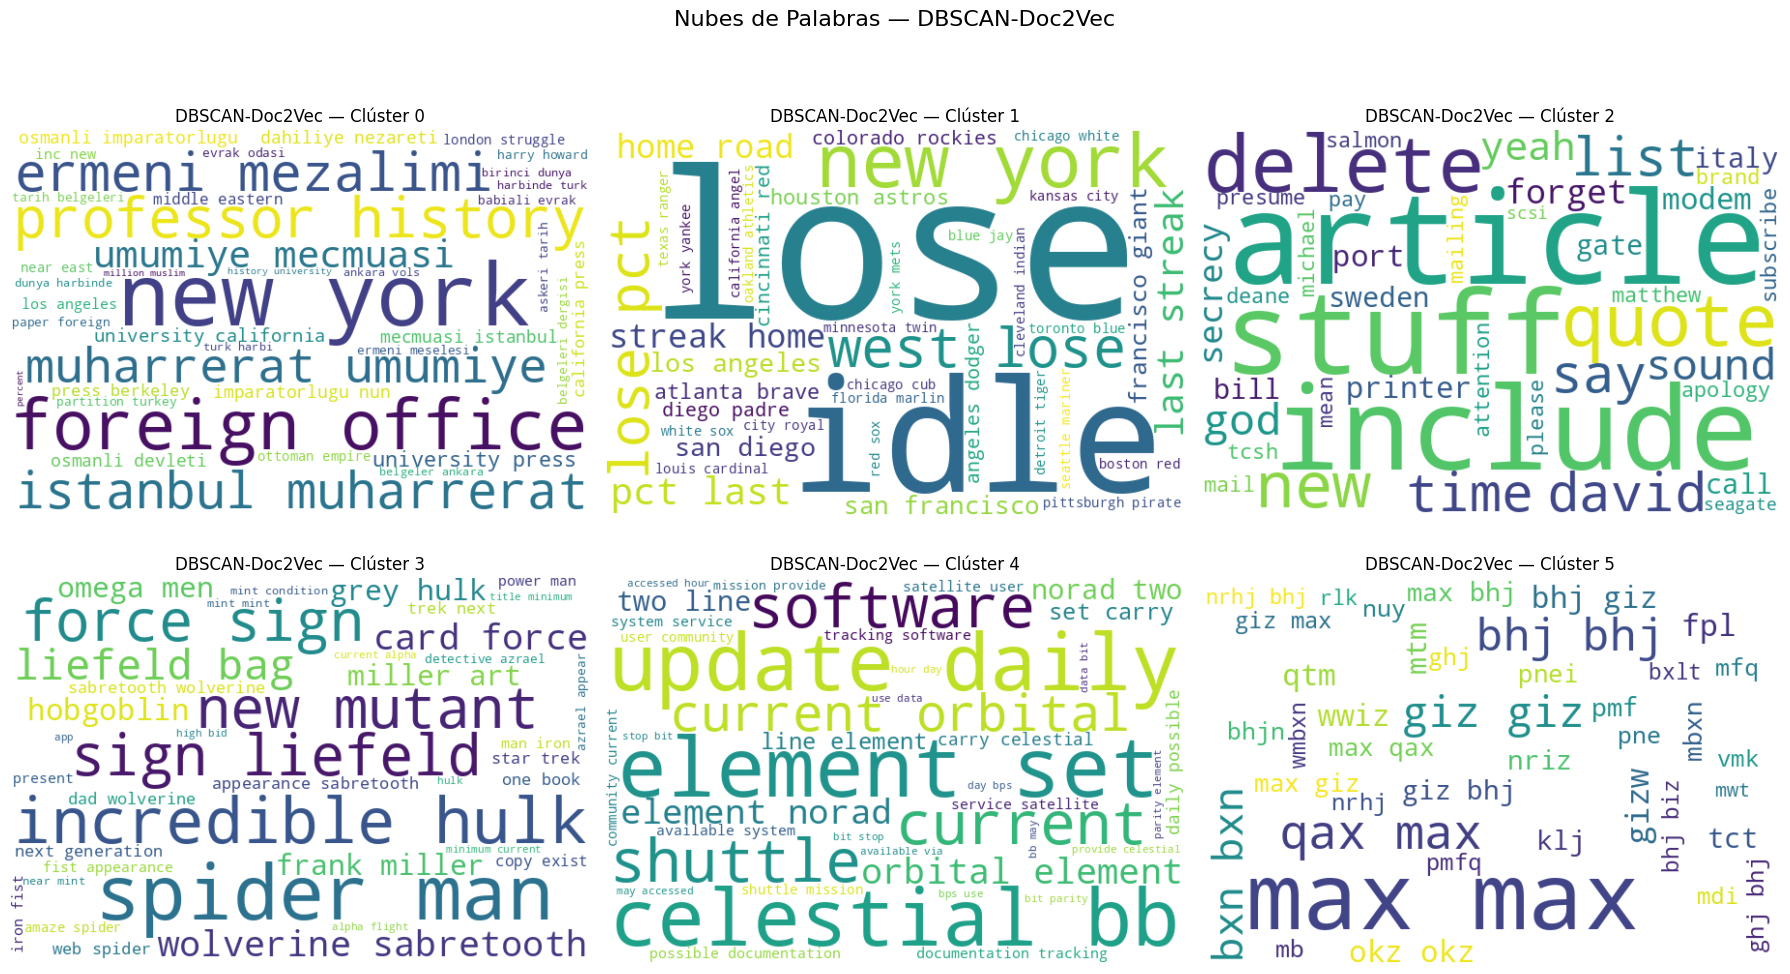

In [78]:
# SECCIÓN 2-4: PIPELINE  PARA DOC2VEC

print("\n" + "#" * 60)
print(" PIPELINE CON DOC2VEC (normalizado L2)")
print("#" * 60)

# --- 2a-2c: Buscar K óptimo + gráficas ----------------------
inertias_d, sil_d, K_opt_d = buscar_k_optimo(X_d2v, K_range, "Doc2Vec")
graficar_codo_silhouette(K_range, inertias_d, sil_d, K_opt_d, "Doc2Vec")

print(f"\n    K óptimo Doc2Vec = {K_opt_d}")
print(f"      Silhouette máximo = {max(sil_d):.4f}")
print(f"      La inercia se estabiliza alrededor de K={K_opt_d},")
print(f"      coincidiendo con el máximo del Coeficiente Silhouette.")

labels_km_d, metrics_km_d = entrenar_kmeans_final(X_d2v, K_opt_d, "Doc2Vec")

best_params_d = buscar_dbscan(X_d2v, "Doc2Vec")
if best_params_d:
    labels_db_d, metrics_db_d = entrenar_dbscan_final(
        X_d2v, best_params_d, "Doc2Vec")
else:
    labels_db_d  = np.full(len(X_d2v), -1)
    metrics_db_d = {'Silhouette': 0, 'DBI': 999, 'CH': 0,
                    'Clústeres': 0, 'Ruido': len(X_d2v)}
    best_params_d = {'eps': 0, 'min_samples': 0}

graficar_pca(X_d2v, labels_km_d, labels_db_d, K_opt_d,
             best_params_d, "Doc2Vec")
graficar_tsne(X_d2v, labels_km_d, labels_db_d, K_opt_d,
              best_params_d, "Doc2Vec")
plot_wordclouds(labels_km_d, corpus_tokens, "KMeans-Doc2Vec")
plot_wordclouds(labels_db_d, corpus_tokens, "DBSCAN-Doc2Vec")

5.	Comparación de resultados

a)	Construye una tabla comparativa donde muestres los valores de las métricas obtenidas con ambos modelos.

b)	Escribe una conclusión técnica, indicando qué algoritmo funcionó mejor basándote en las métricas, no en opinión personal.


In [85]:
# SECCIÓN 5: COMPARACIÓN GLOBAL DE RESULTADOS

print("\n" + "=" * 60)
print("SECCIÓN 5: Comparación global de resultados")
print("=" * 60)

# 5a) Tabla comparativa
tabla = pd.DataFrame({
    'Modelo':             ['K-Means', 'DBSCAN', 'K-Means', 'DBSCAN'],
    'Embedding':          ['Word2Vec', 'Word2Vec', 'Doc2Vec', 'Doc2Vec'],
    'Normalización':      ['L2', 'L2', 'L2', 'L2'],
    'K / Clústeres':      [K_opt_w,
                           metrics_db_w.get('Clústeres', '-'),
                           K_opt_d,
                           metrics_db_d.get('Clústeres', '-')],
    'Ruido':              [0,
                           metrics_db_w.get('Ruido', '-'),
                           0,
                           metrics_db_d.get('Ruido', '-')],
    'Silhouette (↑)':     [f"{metrics_km_w['Silhouette']:.4f}",
                           f"{metrics_db_w['Silhouette']:.4f}",
                           f"{metrics_km_d['Silhouette']:.4f}",
                           f"{metrics_db_d['Silhouette']:.4f}"],
    'Davies-Bouldin (↓)': [f"{metrics_km_w['DBI']:.4f}",
                           f"{metrics_db_w['DBI']:.4f}",
                           f"{metrics_km_d['DBI']:.4f}",
                           f"{metrics_db_d['DBI']:.4f}"],
    'Calinski-H (↑)':     [f"{metrics_km_w['CH']:.2f}",
                           f"{metrics_db_w['CH']:.2f}",
                           f"{metrics_km_d['CH']:.2f}",
                           f"{metrics_db_d['CH']:.2f}"]
})

print("\n" + tabla.to_string(index=False))



SECCIÓN 5: Comparación global de resultados

 Modelo Embedding Normalización  K / Clústeres  Ruido Silhouette (↑) Davies-Bouldin (↓) Calinski-H (↑)
K-Means  Word2Vec            L2              2      0         0.1079             2.7683        2156.34
 DBSCAN  Word2Vec            L2              4   2213         0.2466             0.8069          27.01
K-Means   Doc2Vec            L2              2      0         0.0430             4.9052         738.36
 DBSCAN   Doc2Vec            L2              9  18132         0.5490             0.6145          80.54
